In [1]:
import pandas as pd
import numpy as np

# 1. Load the Dataset
print("Loading dataset... (This might take a minute depending on your RAM)")
# Make sure the file name matches exactly what you downloaded
df = pd.read_csv('/kaggle/input/datasets/wajahatalitariq/train-test-network/train_test_network.csv', low_memory=False)

# Convert those Zeek/Bro dashes into standard mathematical Nulls (NaN)
df.replace('-', np.nan, inplace=True)

print("\n==================================================")
print("             DATASET DIAGNOSTIC REPORT            ")
print("==================================================\n")

# --- TEST 1: The Size of the Problem ---
print("--- 1. DATASET SHAPE ---")
print(f"Total Rows (Packets/Events): {df.shape[0]:,}")
print(f"Total Columns (Features): {df.shape[1]}\n")

# --- TEST 2: Text vs. Numbers ---
# Deep learning needs numbers. This tells us how much text we have to encode later.
text_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['number']).columns

print("--- 2. DATA TYPES ---")
print(f"Text/Categorical Columns to Encode: {len(text_cols)}")
print(f"Numerical Columns ready for Scaling: {len(num_cols)}\n")

# --- TEST 3: The "Null" X-Ray ---
# This calculates exactly what percentage of each column is empty
print("--- 3. MISSING DATA (THE NULL X-RAY) ---")
missing_percentages = df.isnull().mean() * 100
missing_heavy = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

if missing_heavy.empty:
    print("Amazing! There is absolutely zero missing data.")
else:
    print("These are the columns with the highest percentage of missing data:")
    # Print the top 15 worst offenders
    print(missing_heavy.head(15).round(2).astype(str) + ' %')
print("\n")

# --- TEST 4: The Class Balance (Normal vs. Attack) ---
# This is crucial. If the dataset is 99% normal and 1% attack, the AI will just guess "normal" every time.
print("--- 4. CLASS DISTRIBUTION (NORMAL vs. ATTACK) ---")
if 'label' in df.columns:
    # label 0 = Normal, label 1 = Attack
    distribution = df['label'].value_counts(normalize=True) * 100
    print(distribution.round(2).astype(str) + ' %')
else:
    print("Could not find a 'label' column to check distribution.")
    
print("\n==================================================")
print("                REPORT COMPLETE                   ")
print("==================================================")

Loading dataset... (This might take a minute depending on your RAM)

             DATASET DIAGNOSTIC REPORT            

--- 1. DATASET SHAPE ---
Total Rows (Packets/Events): 211,043
Total Columns (Features): 44

--- 2. DATA TYPES ---
Text/Categorical Columns to Encode: 27
Numerical Columns ready for Scaling: 17

--- 3. MISSING DATA (THE NULL X-RAY) ---
These are the columns with the highest percentage of missing data:
ssl_subject             99.99 %
ssl_issuer              99.99 %
http_orig_mime_types    99.99 %
weird_addl              99.93 %
http_resp_mime_types     99.9 %
http_uri                99.86 %
http_method             99.86 %
http_user_agent         99.86 %
http_version            99.86 %
http_trans_depth        99.86 %
weird_name              99.83 %
weird_notice            99.83 %
ssl_version             99.81 %
ssl_cipher              99.81 %
ssl_resumed             99.81 %
dtype: object


--- 4. CLASS DISTRIBUTION (NORMAL vs. ATTACK) ---
label
1    76.31 %
0    23.69 %

In [2]:
import pandas as pd
import numpy as np

# 1. Convert Zeek/Bro dashes to real mathematical Nulls
df.replace('-', np.nan, inplace=True)

# ---------------------------------------------------------
# STRATEGY 1: DROP EMPTY COLUMNS (From the X-Ray)
# ---------------------------------------------------------
print("Executing Strategy 1: Dropping heavily empty columns...")

# Calculate missing percentages
missing_percentages = df.isnull().mean() * 100

# Set our threshold to 60%. Get the names of the columns that fail the test.
threshold = 60
columns_to_drop = missing_percentages[missing_percentages > threshold].index

# Drop them from the dataset
df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped {len(columns_to_drop)} mostly empty columns.")

# ---------------------------------------------------------
# STRATEGY 2: DROP IDENTIFIERS ("Cheat" Features)
# ---------------------------------------------------------
print("Executing Strategy 2: Dropping network identifiers...")

# We drop IPs, Ports, and Timestamps so the AI learns behavior, not memorization.
identifiers = ['ts', 'src_ip', 'dst_ip', 'src_port', 'dst_port']

# errors='ignore' ensures it doesn't crash if one of these was already dropped
df.drop(columns=identifiers, inplace=True, errors='ignore')

# ---------------------------------------------------------
# FINAL CLEANUP
# ---------------------------------------------------------
# Drop exact duplicate rows to prevent overfitting
df.drop_duplicates(inplace=True)

# Drop any remaining rows that have a random NaN value
df.dropna(inplace=True)

print("\n--- CLEANUP COMPLETE ---")
print(f"New Dataset Shape: {df.shape}")

Executing Strategy 1: Dropping heavily empty columns...
Dropped 22 mostly empty columns.
Executing Strategy 2: Dropping network identifiers...

--- CLEANUP COMPLETE ---
New Dataset Shape: (93590, 18)


In [3]:
from sklearn.preprocessing import LabelEncoder

print("Executing Strategy 3: Translating Text to Numbers...")

# 1. Find all the columns that still contain text (objects)
text_columns = df.select_dtypes(include=['object']).columns
print(f"Found {len(text_columns)} text columns to encode: {list(text_columns)}")

# 2. Create our translator (LabelEncoder)
encoder = LabelEncoder()

# 3. Loop through every text column and translate it into numbers
for col in text_columns:
    # We convert to string first just in case there's a weird hidden value
    df[col] = encoder.fit_transform(df[col].astype(str))

# 4. Verify the results
print("\n--- ENCODING COMPLETE ---")
# This will check if there is any text left in the entire dataset
remaining_text = df.select_dtypes(include=['object']).columns

if len(remaining_text) == 0:
    print("Success! Your entire dataset is now 100% mathematical numbers.")
else:
    print(f"Wait, something was missed: {list(remaining_text)}")

# Let's look at the first 5 rows to see our new, fully numerical data!
display(df.head())

Executing Strategy 3: Translating Text to Numbers...
Found 3 text columns to encode: ['proto', 'conn_state', 'type']

--- ENCODING COMPLETE ---
Success! Your entire dataset is now 100% mathematical numbers.


,proto,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label,type
0,1,290.371539,101568,2592,0,0,108,108064,31,3832,0,0,0,0,0,0,1,0
1,1,0.000102,0,0,1,0,1,52,1,40,0,0,0,0,0,0,1,0
2,1,0.000148,0,0,1,0,1,52,1,40,0,0,0,0,0,0,1,0
3,1,0.000113,0,0,1,0,1,48,1,40,0,0,0,0,0,0,1,0
4,1,0.000130,0,0,1,0,1,52,1,40,0,0,0,0,0,0,1,0


In [5]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

print("Executing Strategy 4: Feature Scaling...")

# 1. Isolate the "Answers" (Labels) so we don't accidentally scale them
# We drop them from the main dataset temporarily
y_label = df['label']
y_type = df['type']
X_features = df.drop(columns=['label', 'type'])

# 2. Create our mathematical compressor (MinMaxScaler)
scaler = MinMaxScaler()

# 3. Scale all the features to a range between 0 and 1
# This outputs a raw numpy array, so we convert it back into a nice Pandas DataFrame
X_scaled = pd.DataFrame(scaler.fit_transform(X_features), columns=X_features.columns)

# 4. Re-attach our labels back to the scaled data
# reset_index ensures the rows match up perfectly after splitting them
df_scaled = pd.concat([X_scaled, y_label.reset_index(drop=True), y_type.reset_index(drop=True)], axis=1)

print("\n--- SCALING COMPLETE ---")
print("Every feature is now perfectly compressed between 0 and 1.")

# Let's look at the first 5 rows to see the magic!
display(df_scaled.head())

Executing Strategy 4: Feature Scaling...

--- SCALING COMPLETE ---
Every feature is now perfectly compressed between 0 and 1.


,proto,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label,type
0,0.5,3.105016e-03,0.000026,6.622629e-07,0.000000,0.0,0.004386,0.016568,0.000254,4.435415e-05,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,0.5,1.090712e-09,0.000000,0.000000e+00,0.083333,0.0,0.000041,0.000008,0.000008,4.629870e-07,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,0.5,1.582601e-09,0.000000,0.000000e+00,0.083333,0.0,0.000041,0.000008,0.000008,4.629870e-07,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3,0.5,1.208337e-09,0.000000,0.000000e+00,0.083333,0.0,0.000041,0.000007,0.000008,4.629870e-07,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4,0.5,1.390123e-09,0.000000,0.000000e+00,0.083333,0.0,0.000041,0.000008,0.000008,4.629870e-07,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("Calculating Algorithmic Class Weights...")

# We use the original y_label from before we tried SMOTE
# y_label contains 0 (Normal) and 1 (Attack)
classes = np.unique(y_label)

# This formula automatically calculates how much harder to penalize the AI 
# when it gets the minority class (Normal) wrong.
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_label)

# Create a dictionary that TensorFlow/PyTorch can easily read
class_weights_dict = {classes[0]: weights[0], classes[1]: weights[1]}

print("\n--- CLASS WEIGHTS GENERATED ---")
print(f"Penalty for misclassifying Normal (0): {class_weights_dict[0]:.4f}")
print(f"Penalty for misclassifying Attack (1): {class_weights_dict[1]:.4f}")

Calculating Algorithmic Class Weights...

--- CLASS WEIGHTS GENERATED ---
Penalty for misclassifying Normal (0): 1.9834
Penalty for misclassifying Attack (1): 0.6685


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split 
from sklearn.utils.class_weight import compute_class_weight

print("Step 1: Reshaping data for the Two-Headed Model...")

# 1. Sequence Generation (Grabbing BOTH labels)
def create_multi_sequences(X, y_bin, y_mul, time_steps=10):
    Xs, y_bins, y_muls = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        y_bins.append(y_bin.iloc[i + time_steps])
        y_muls.append(y_mul.iloc[i + time_steps])
    return np.array(Xs), np.array(y_bins), np.array(y_muls)

TIME_STEPS = 10
# Assuming y_type is your multiclass label series and y_label is your binary label series
NUM_CLASSES = len(np.unique(y_type)) 

X_seq, y_bin_seq, y_mul_seq = create_multi_sequences(X_features, y_label, y_type, TIME_STEPS)
print(f"3D Shape ready: {X_seq.shape}")
print(f"Total Attack Categories to predict: {NUM_CLASSES}")

# ---------------------------------------------------------
# Step 1.5: CALCULATE BINARY AND MULTICLASS PENALTIES
# ---------------------------------------------------------
print("\nCalculating Algorithmic Penalties...")

# --- Binary Penalties ---
bin_classes = np.unique(y_bin_seq)
bin_weights = compute_class_weight(class_weight='balanced', classes=bin_classes, y=y_bin_seq)
class_weights_dict = {bin_classes[i]: bin_weights[i] for i in range(len(bin_classes))}

# --- Multiclass Penalties ---
mc_classes = np.unique(y_mul_seq)
mc_weights = compute_class_weight(class_weight='balanced', classes=mc_classes, y=y_mul_seq)
multiclass_weights_dict = {mc_classes[i]: mc_weights[i] for i in range(len(mc_classes))}

print(f"Original Penalty for Class 4: {multiclass_weights_dict.get(4, 0):.4f}")
print(f"Original Penalty for Class 7: {multiclass_weights_dict.get(7, 0):.4f}")

# ---> THE FIX: Dampen the paranoid weights for the minority classes <---
if 4 in multiclass_weights_dict:
    multiclass_weights_dict[4] = multiclass_weights_dict[4] * 0.5 
    print(f"New Dampened Penalty for Class 4: {multiclass_weights_dict[4]:.4f}")

if 7 in multiclass_weights_dict:
    # Dampening Class 7 to fix its low Precision/high Recall trade-off
    multiclass_weights_dict[7] = multiclass_weights_dict[7] * 0.6 
    print(f"New Dampened Penalty for Class 7: {multiclass_weights_dict[7]:.4f}")

# ---------------------------------------------------------
# Step 2: BUILDING THE TWO-HEADED ARCHITECTURE
# ---------------------------------------------------------
print("\nStep 2: Constructing the CNN-BiLSTM-Transformer Multi-Task Model...")

num_features = X_seq.shape[2]
inputs = Input(shape=(TIME_STEPS, num_features))

# THE CORE ENGINE
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

attention_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization(epsilon=1e-6)(attention_output + x)

x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)

# THE TWO OUTPUT HEADS
binary_head = Dense(1, activation='sigmoid', name='binary_output')(x)
multiclass_head = Dense(NUM_CLASSES, activation='softmax', name='multiclass_output')(x)

# Clean, single compile
sentinel_model = Model(inputs=inputs, outputs=[binary_head, multiclass_head])
sentinel_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    metrics=['accuracy', 'accuracy']
)

# ---------------------------------------------------------
# Step 3: THE SHUFFLED TF.DATA PIPELINES
# ---------------------------------------------------------
print("\n--- STEP 3: SHUFFLING & BUILDING STRICT PIPELINES ---")

# 1. Randomly shuffle and split the 3D sequences 80/20
X_train, X_val, y_bin_train, y_bin_val, y_mul_train, y_mul_val = train_test_split(
    X_seq, y_bin_seq, y_mul_seq, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_bin_seq 
)

# 2. Apply the strict penalties ONLY to the training data
sw_bin_train = np.array([class_weights_dict[int(label)] for label in y_bin_train], dtype=np.float32)
sw_mul_train = np.array([multiclass_weights_dict[int(label)] for label in y_mul_train], dtype=np.float32)

sw_bin_val = np.ones(len(y_bin_val), dtype=np.float32)
sw_mul_val = np.ones(len(y_mul_val), dtype=np.float32)

# 3. Build the TensorFlow Pipelines using TUPLES ()
train_dataset = tf.data.Dataset.from_tensor_slices((
    X_train,
    (y_bin_train, y_mul_train),      
    (sw_bin_train, sw_mul_train)     
)).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((
    X_val,
    (y_bin_val, y_mul_val),
    (sw_bin_val, sw_mul_val)
)).batch(64).prefetch(tf.data.AUTOTUNE)

# ---------------------------------------------------------
# Step 4: TRAIN THE AI
# ---------------------------------------------------------
print("\n--- STARTING DUAL-TRAINING PROCESS ---")

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Start the training!
history = sentinel_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop]
)

print("\nMulti-Task Training Complete! Sentinel-IoT is ready.")

2026-05-17 20:38:50.399388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779050330.592500      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779050330.647224      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779050331.106929      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779050331.106955      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779050331.106958      57 computation_placer.cc:177] computation placer alr

Step 1: Reshaping data for the Two-Headed Model...
3D Shape ready: (93580, 10, 16)
Total Attack Categories to predict: 10

Calculating Algorithmic Penalties...
Original Penalty for Class 4: 9.0766
Original Penalty for Class 7: 35.9923
New Dampened Penalty for Class 4: 4.5383
New Dampened Penalty for Class 7: 21.5954

Step 2: Constructing the CNN-BiLSTM-Transformer Multi-Task Model...


I0000 00:00:1779050362.678995      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



--- STEP 3: SHUFFLING & BUILDING STRICT PIPELINES ---

--- STARTING DUAL-TRAINING PROCESS ---
Epoch 1/50


I0000 00:00:1779050368.940231     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


1170/1170 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - binary_output_accuracy: 0.8837 - binary_output_loss: 0.2782 - loss: 1.5139 - multiclass_output_accuracy: 0.5623 - multiclass_output_loss: 1.2357 - val_binary_output_accuracy: 0.9793 - val_binary_output_loss: 0.0604 - val_loss: 0.5594 - val_multiclass_output_accuracy: 0.8295 - val_multiclass_output_loss: 0.4985
Epoch 2/50
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - binary_output_accuracy: 0.9682 - binary_output_loss: 0.0935 - loss: 0.7701 - multiclass_output_accuracy: 0.7683 - multiclass_output_loss: 0.6767 - val_binary_output_accuracy: 0.9822 - val_binary_output_loss: 0.0463 - val_loss: 0.4305 - val_multiclass_output_accuracy: 0.8634 - val_multiclass_output_loss: 0.3836
Epoch 3/50
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - binary_output_accuracy: 0.9782 - binary_output_loss: 0.0644 - loss: 0.5664 - multiclass_output_accuracy: 0.8261 - multiclass_output_loss: 0.5020 - val_binary_output_accuracy: 0.9845 - val_binary_output_loss: 0.039

--- 1. SAVING THE MODEL FOR WAZUH ---
Success: Model saved as 'sentinel_iot_model.keras'.

--- 2. GENERATING PREDICTIONS ---
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

      ZERO-DAY DETECTION (BINARY) REPORT
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99      4719
  Attack (1)       1.00      1.00      1.00     13997

    accuracy                           0.99     18716
   macro avg       0.99      0.99      0.99     18716
weighted avg       0.99      0.99      0.99     18716


   FORENSIC CLASSIFICATION (MULTICLASS) REPORT
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       380
           1       0.97      0.95      0.96      2468
           2       0.97      0.95      0.96      1317
           3       0.98      0.96      0.97      3835
           4       0.56      0.85      0.68       212
           5       1.00      0.98      0.99      4719
           6       0.97      0.99     

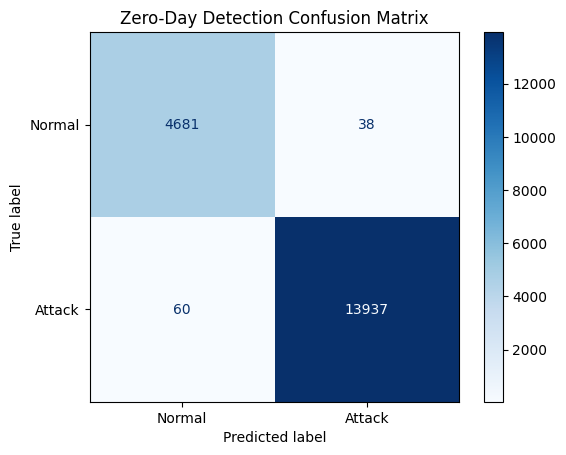

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("--- 1. SAVING THE MODEL FOR WAZUH ---")
# Saves the entire brain, weights, and architecture to a single file!
sentinel_model.save('sentinel_iot_model.keras')
print("Success: Model saved as 'sentinel_iot_model.keras'.\n")

print("--- 2. GENERATING PREDICTIONS ---")
# We ask the AI to take the final "Exam" using the validation dataset
predictions = sentinel_model.predict(val_dataset)

# Head 1 outputs a percentage (e.g. 0.99), we round it to exactly 1 or 0
y_pred_bin = np.round(predictions[0]).flatten()

# Head 2 outputs 10 probabilities. We use argmax to pick the highest one!
y_pred_mul = np.argmax(predictions[1], axis=1)

print("\n======================================================")
print("      ZERO-DAY DETECTION (BINARY) REPORT")
print("======================================================")
# The jury cares deeply about "Recall" and "F1-Score", not just Accuracy!
print(classification_report(y_bin_val, y_pred_bin, target_names=['Normal (0)', 'Attack (1)']))

print("\n======================================================")
print("   FORENSIC CLASSIFICATION (MULTICLASS) REPORT")
print("======================================================")
print(classification_report(y_mul_val, y_pred_mul))

print("\n--- 3. DRAWING CONFUSION MATRIX ---")
# This creates the visual grid showing exactly what the AI got right vs. wrong
cm = confusion_matrix(y_bin_val, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Zero-Day Detection Confusion Matrix")
plt.show()

Generating predictions from the AI...
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Drawing Confusion Matrix...


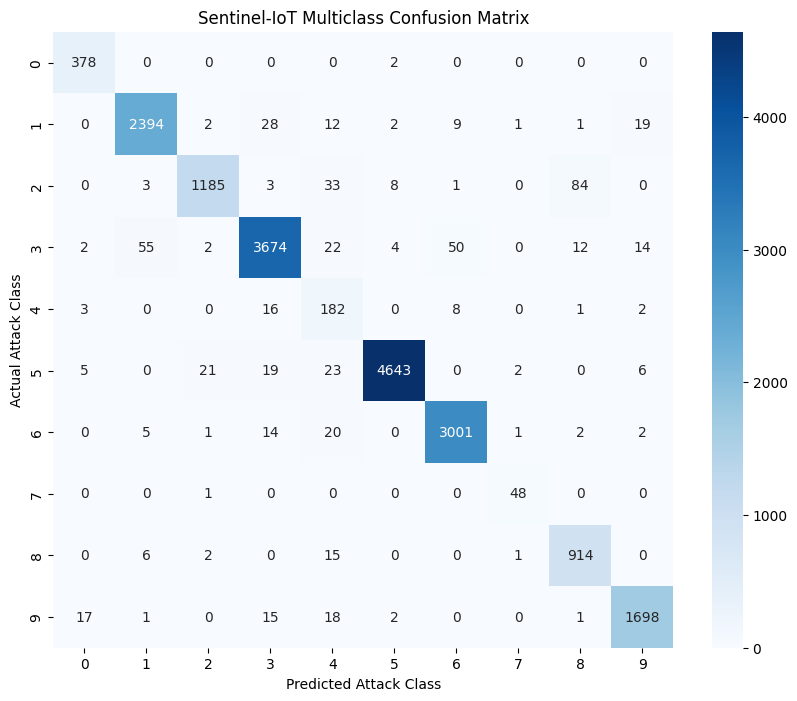

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("Generating predictions from the AI...")

# 1. Ask the model to predict the validation dataset
# Your model has two heads, so it outputs a list: [binary_predictions, multiclass_predictions]
predictions = sentinel_model.predict(val_dataset)
multiclass_predictions = predictions[1] # We only want the multiclass head for this matrix

# 2. The AI outputs percentages (softmax). We want the class with the highest percentage.
y_pred_classes = np.argmax(multiclass_predictions, axis=1)

# 3. Define the actual true answers from your validation split
y_true_classes = y_mul_val 

print("Drawing Confusion Matrix...")

# 4. Generate and plot the matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Sentinel-IoT Multiclass Confusion Matrix')
plt.ylabel('Actual Attack Class')
plt.xlabel('Predicted Attack Class')
plt.show()

In [9]:
import numpy as np
import pandas as pd

print("--- 1. SAVING PREPROCESSED 3D DATASETS ---")
# Saving as .npy files is 100x faster to load later than a CSV
np.save('/kaggle/working/X_seq.npy', X_seq)
np.save('/kaggle/working/y_bin_seq.npy', y_bin_seq)
np.save('/kaggle/working/y_mul_seq.npy', y_mul_seq)
print("✅ Success: 3D Numpy arrays saved!")

print("\n--- 2. SAVING THE 2D CSV (For your records) ---")
# Recombining features and labels to save a clean spreadsheet
df_final_export = X_features.copy()
df_final_export['label'] = y_label
df_final_export['type'] = y_type
df_final_export.to_csv('/kaggle/working/ToN_IoT_Preprocessed_Scaled.csv', index=False)
print("✅ Success: 2D CSV Dataset saved!")

print("\n--- 3. SAVING THE TRAINED AI BRAIN ---")
# Saves the entire neural network, weights, and architecture to a single file
sentinel_model.save('/kaggle/working/sentinel_iot_model.keras')
print("✅ Success: AI Model saved as 'sentinel_iot_model.keras'!")

--- 1. SAVING PREPROCESSED 3D DATASETS ---
✅ Success: 3D Numpy arrays saved!

--- 2. SAVING THE 2D CSV (For your records) ---
✅ Success: 2D CSV Dataset saved!

--- 3. SAVING THE TRAINED AI BRAIN ---
✅ Success: AI Model saved as 'sentinel_iot_model.keras'!


In [12]:
import shutil

# This will zip the entire working directory into a single file named 'my_project_outputs.zip'
shutil.make_archive('sentinel_iot_model.keras', 'zip', '/kaggle/working')

KeyboardInterrupt: 

--- GENERATING LEARNING CURVES ---


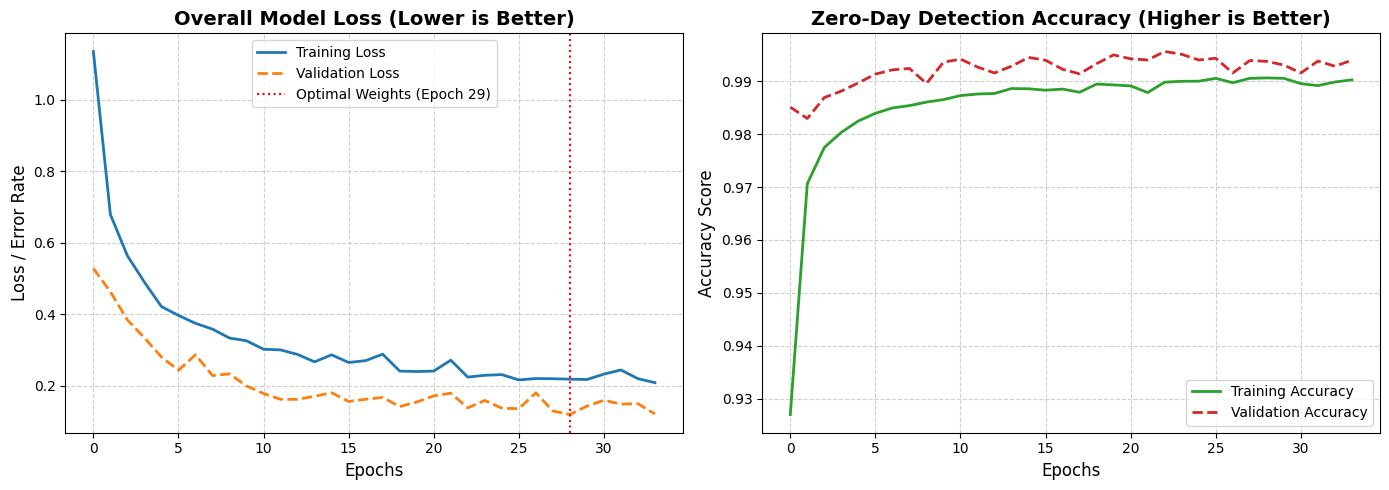

In [22]:
import matplotlib.pyplot as plt

print("--- GENERATING LEARNING CURVES ---")

# Extract the data recorded during your training process
history_dict = history.history

plt.figure(figsize=(14, 5))

# ---------------------------------------------------------
# GRAPH 1: LOSS (The Ultimate Overfitting Detector)
# ---------------------------------------------------------
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history_dict['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='dashed')

# We draw a line where the AI peaked (Epoch 36 - Note: Python index starts at 0, so epoch 36 is index 35)
best_epoch = np.argmin(history_dict['val_loss']) 
plt.axvline(x=best_epoch, color='red', linestyle='dotted', label=f'Optimal Weights (Epoch {best_epoch + 1})')

plt.title('Overall Model Loss (Lower is Better)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss / Error Rate', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# GRAPH 2: BINARY ACCURACY
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(history_dict['binary_output_accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history_dict['val_binary_output_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2, linestyle='dashed')

plt.title('Zero-Day Detection Accuracy (Higher is Better)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.utils.class_weight import compute_class_weight

print("Calculating Multi-class Penalty Weights...")

# Find all unique classes (0 through 9)
mc_classes = np.unique(y_mul_seq)

# Calculate how hard to penalize the AI for each specific attack
mc_weights = compute_class_weight(class_weight='balanced', classes=mc_classes, y=y_mul_seq)

# Create the dictionary
multiclass_weights_dict = {mc_classes[i]: mc_weights[i] for i in range(len(mc_classes))}

print(f"Penalty for Class 1: {multiclass_weights_dict[0]:.4f}")
print(f"Penalty for Class 2: {multiclass_weights_dict[1]:.4f}")
print(f"Penalty for Class 3: {multiclass_weights_dict[2]:.4f}")
print(f"Penalty for Class 4: {multiclass_weights_dict[3]:.4f}")
print(f"Penalty for Class 5: {multiclass_weights_dict[4]:.4f}")
print(f"Penalty for Class 6: {multiclass_weights_dict[5]:.4f}")
print(f"Penalty for Class 7: {multiclass_weights_dict[6]:.4f}")
print(f"Penalty for Class 8: {multiclass_weights_dict[7]:.4f}")
print(f"Penalty for Class 9: {multiclass_weights_dict[8]:.4f}")


Calculating Multi-class Penalty Weights...
Penalty for Class 1: 4.7843
Penalty for Class 2: 0.7823
Penalty for Class 3: 1.4513
Penalty for Class 4: 0.4715
Penalty for Class 5: 9.0766
Penalty for Class 6: 0.3966
Penalty for Class 7: 0.6137
Penalty for Class 8: 35.9923
Penalty for Class 9: 2.0828


Drawing Class Distribution Bar Chart...


/tmp/ipykernel_55/2260926939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', ax=axes[0])
/tmp/ipykernel_55/2260926939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='magma', ax=axes[1])


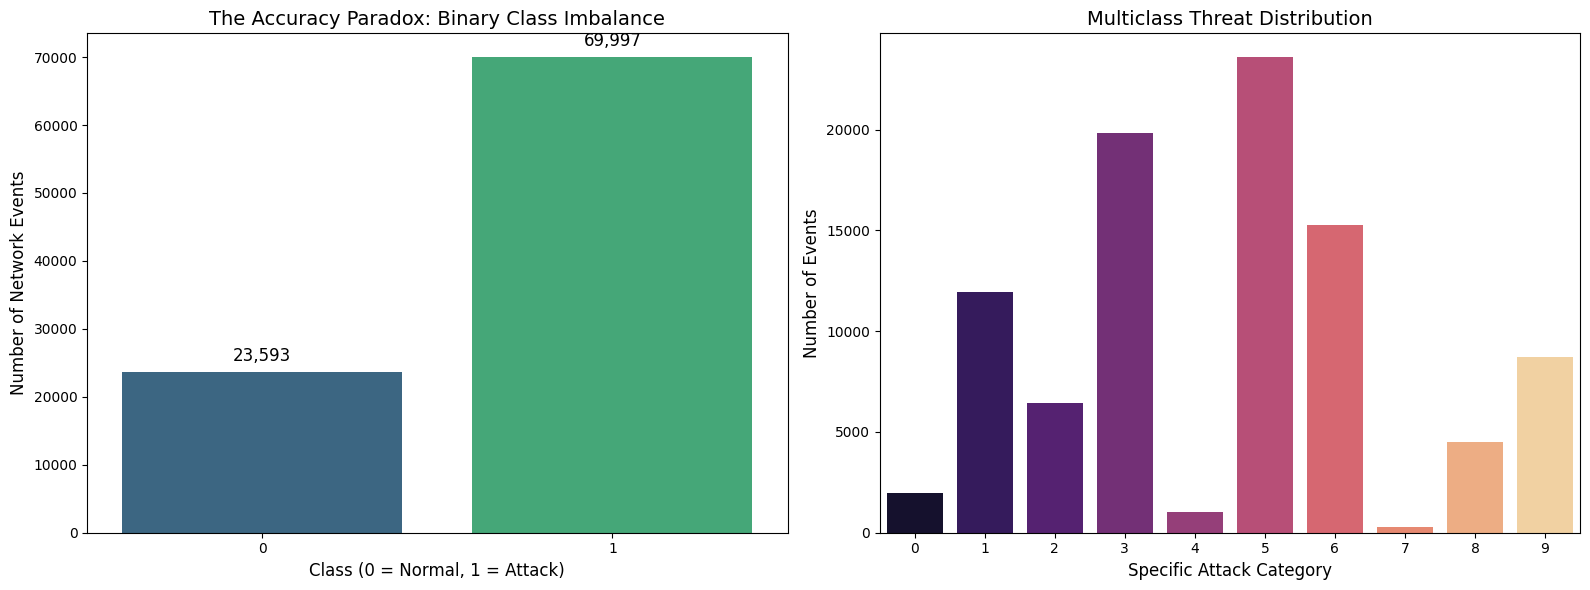

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Drawing Class Distribution Bar Chart...")

# Create a figure with two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Binary Imbalance
sns.countplot(data=df, x='label', palette='viridis', ax=axes[0])
axes[0].set_title("The Accuracy Paradox: Binary Class Imbalance", fontsize=14)
axes[0].set_xlabel("Class (0 = Normal, 1 = Attack)", fontsize=12)
axes[0].set_ylabel("Number of Network Events", fontsize=12)

# Adding exact numbers on top of the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Chart 2: Multiclass Imbalance (Feature Camouflage context)
sns.countplot(data=df, x='type', palette='magma', ax=axes[1])
axes[1].set_title("Multiclass Threat Distribution", fontsize=14)
axes[1].set_xlabel("Specific Attack Category", fontsize=12)
axes[1].set_ylabel("Number of Events", fontsize=12)

plt.tight_layout()
plt.show()

Drawing Feature Correlation Heatmap...


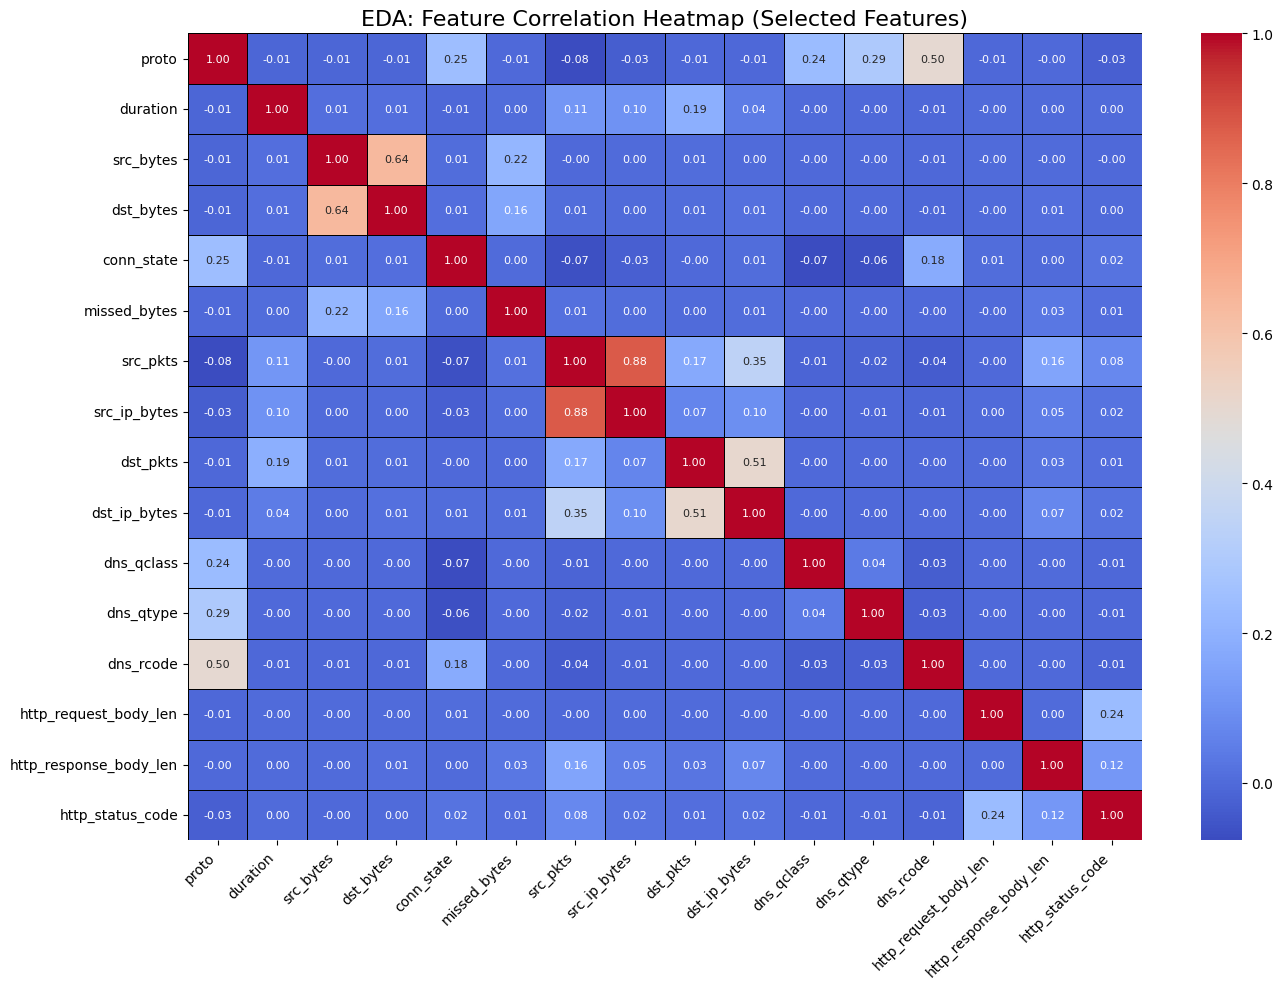

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Drawing Feature Correlation Heatmap...")

# Compute the correlation matrix for the top scaled features
plt.figure(figsize=(14, 10))
corr_matrix = X_scaled.corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, linecolor='black', annot_kws={"size": 8})
plt.title("EDA: Feature Correlation Heatmap (Selected Features)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Drawing Feature Distribution Box Plots...


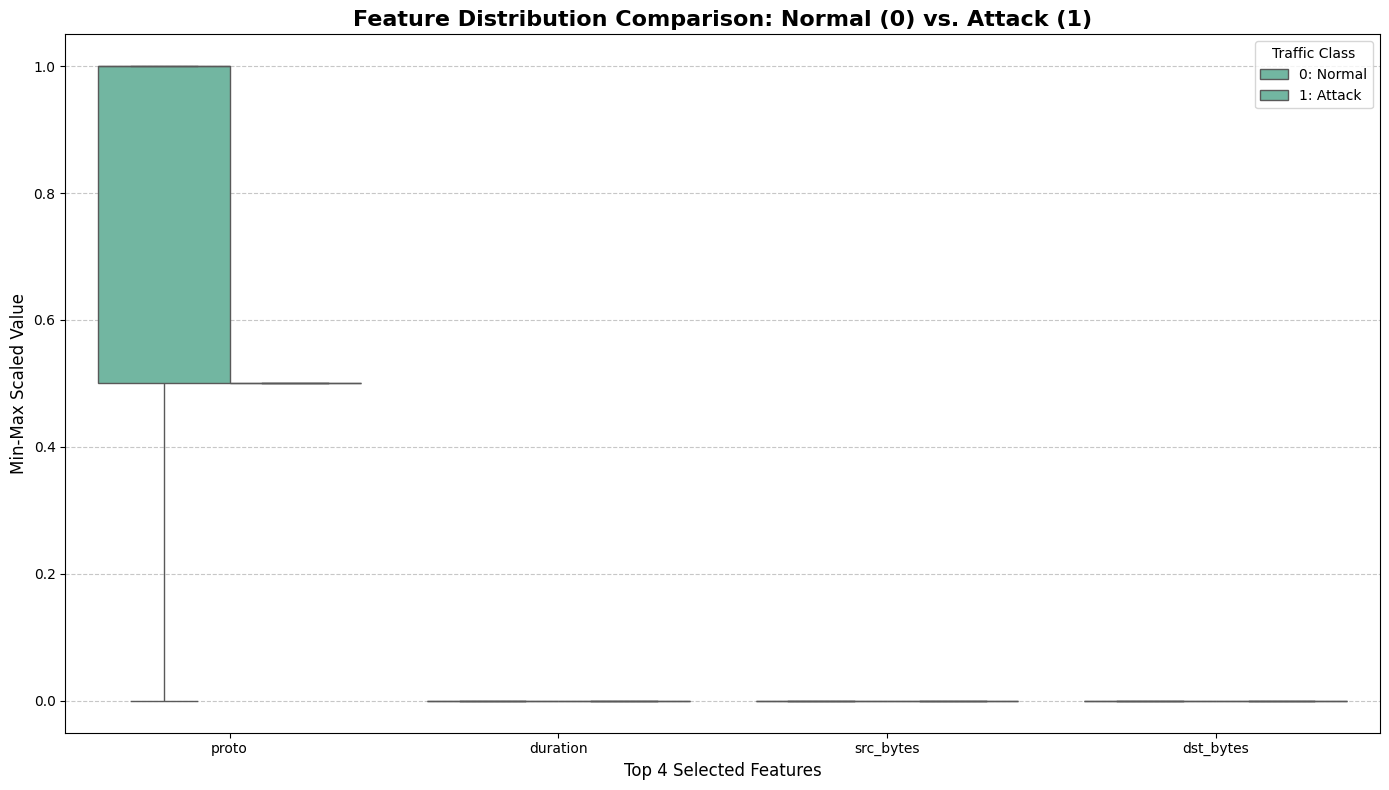

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Drawing Feature Distribution Box Plots...")

# 1. Select the top 4 features from your scaled dataset
# (Assuming X_scaled is your DataFrame of the 16 features and y_label is your binary target)
top_4_features = X_scaled.columns[:4] 

# 2. Combine them temporarily with the binary label for plotting
plot_df = X_scaled[top_4_features].copy()
plot_df['Label'] = y_label.values

# 3. Reshape the data for Seaborn (Melt)
melted_df = pd.melt(plot_df, id_vars=['Label'], value_vars=top_4_features, 
                    var_name='Feature', value_name='Scaled Value')

# 4. Draw the Box Plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Feature', y='Scaled Value', hue='Label', data=melted_df, palette='Set2', showfliers=False)

# Add titles and labels
plt.title("Feature Distribution Comparison: Normal (0) vs. Attack (1)", fontsize=16, fontweight='bold')
plt.xlabel("Top 4 Selected Features", fontsize=12)
plt.ylabel("Min-Max Scaled Value", fontsize=12)
plt.legend(title='Traffic Class', labels=['0: Normal', '1: Attack'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()